# Notebook 03 - Stress Analysis, FEA Results, and ASME B31.3 Compliance

This is the first detailed solver notebook. It builds a piping model, loads or runs Code_Aster through the shared notebook helper, and only then displays stress, displacement, reaction, and compliance results.

You will do five things:

1. Build an operating load case for a restrained L-shaped pipe.
2. Load or run Code_Aster result artifacts.
3. Open the primary deformed-stress review view.
4. Inspect supplemental stress, displacement, and reaction views.
5. Run ASME B31.3 compliance and SIF traceability checks.


## 1. Environment Setup & Imports

In [1]:
import sys
from pathlib import Path
import pyvista as pv

# Setup repo root for path import
REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tuba import Model
from tuba.analysis.code_aster_notebook import configure_code_aster_notebook_runtime, load_or_run_code_aster_results
from tuba.compliance.asme_b313 import ASMEB313Evaluator
from tuba.compliance.sif import compute_sifs
from tuba.plotting import plots

# Enable interactive notebook rendering
# Defaults to zoomable embedded HTML locally; set TUBA_NOTEBOOK_BACKEND=client or static to override.
from tuba.plotting.notebook import configure_notebook_backend
JUPYTER_BACKEND = configure_notebook_backend()

## 2. Building the Piping Model

We'll build a standard L-shaped piping layout with anchors at both ends and a lateral guide restraint close to the bend.

In [2]:
model = Model("StressDemo", standard="ASME_B31.3")

# Material P265GH (allowable stress at different temperatures in Pa)
model.add_material(
    "P265GH",
    E=2.0e11,     # Young's modulus [Pa]
    nu=0.3,       # Poisson's ratio
    rho=7850.0,   # density [kg/m3]
    alpha=1.2e-5, # thermal expansion [1/K]
    allowable_stress={20.0: 137e6, 200.0: 120e6}
)

# Section: 4-inch Schedule 40
model.add_pipe_section("4inch_sch40", OD=0.1143, WT=0.00602, corrosion_allowance=0.001)

# Routing the L-shape pipe
with model.pipe(section="4inch_sch40", material="P265GH") as b:
    b.start([0, 0, 0], support="anchor")
    b.run(5.0)
    b.bend(radius=0.2, angle=90.0, plane="XY")
    b.run(3.0)
    b.end(support="anchor")

# Add a guide support at node N2 (the exit node of the bend)
model.add_support("N2", type="guide")

# Define operating load case
model.define_load_case("Operating", gravity=True, pressure=1.5e6, temperature=200.0)

print(model)

TubaModel('StressDemo', 4 nodes, 3 elements, 3 supports)


## 3. Load or Run Code_Aster Results

This notebook does not synthesize solver values. The next cell exports Code_Aster input files if needed, imports existing Code_Aster output tables from the same work directory, or runs the configured Code_Aster runtime when tables are missing.


In [3]:
CODE_ASTER_RUNTIME = configure_code_aster_notebook_runtime()
# VS Code/Jupyter review defaults to committed real Code_Aster artifacts; set True only after the runtime doctor passes.
RUN_CODE_ASTER = False
CODE_ASTER_WORK_DIR = REPO_ROOT / "notebooks" / "code_aster_results" / "stress_analysis_operating"

code_aster_run = load_or_run_code_aster_results(
    model,
    "Operating",
    CODE_ASTER_WORK_DIR,
    run_solver=RUN_CODE_ASTER,
    exec_method=CODE_ASTER_RUNTIME.exec_method,
    wsl_distro=CODE_ASTER_RUNTIME.wsl_distro,
    docker_image=CODE_ASTER_RUNTIME.docker_image,
)
results = code_aster_run.results
code_aster_artifact = code_aster_run.artifact

if code_aster_run.ran_solver:
    print("Code_Aster solver executed for this notebook run.")
print(f"Loaded Code_Aster results from: {CODE_ASTER_WORK_DIR.resolve()}")
print(f"Node result count: {len(results.node_results)}")
print(f"Element result count: {len(results.element_results)}")

tuyau_subpoints = code_aster_artifact.result_state.metadata.get("tuyau_subpoints", [])
print(f"TUYAU sub-point rows: {len(tuyau_subpoints)}")
if tuyau_subpoints:
    first = tuyau_subpoints[0]
    print(f"First TUYAU sub-point position source: {first.get('position_source')}")
    print(f"First TUYAU sub-point shell display position: {first.get('display_position')}")

Loaded Code_Aster results from: D:\Gitprojects\Tuba_v4\notebooks\code_aster_results\stress_analysis_operating
Node result count: 4
Element result count: 3
TUYAU sub-point rows: 12474
First TUYAU sub-point position source: code_aster_tuyau_subpoint_formula
First TUYAU sub-point shell display position: [0.0, 0.0, 0.05113]


## 4. Interactive Result Review

Start with the combined deformed-stress view. The separate views below are useful when you need to isolate deformation, stress contours, displacement vectors, or reactions.


### A. Primary View: Combined Deformed Stress

This is the fastest engineering review view: warped geometry colored by Code_Aster stress output.


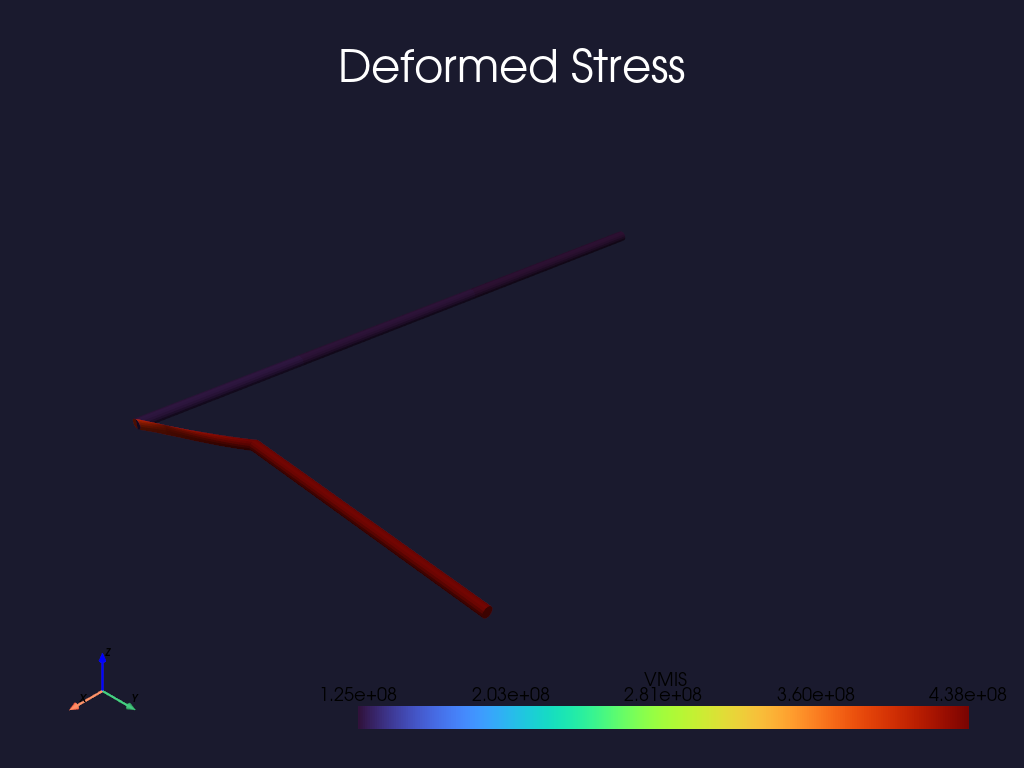

In [4]:
plots.plot_deformed_stress(results, deform_scale=100.0, model=model, jupyter_backend=JUPYTER_BACKEND)

### B. Deformed Shape Only

Use this when displacement shape matters more than stress coloring.


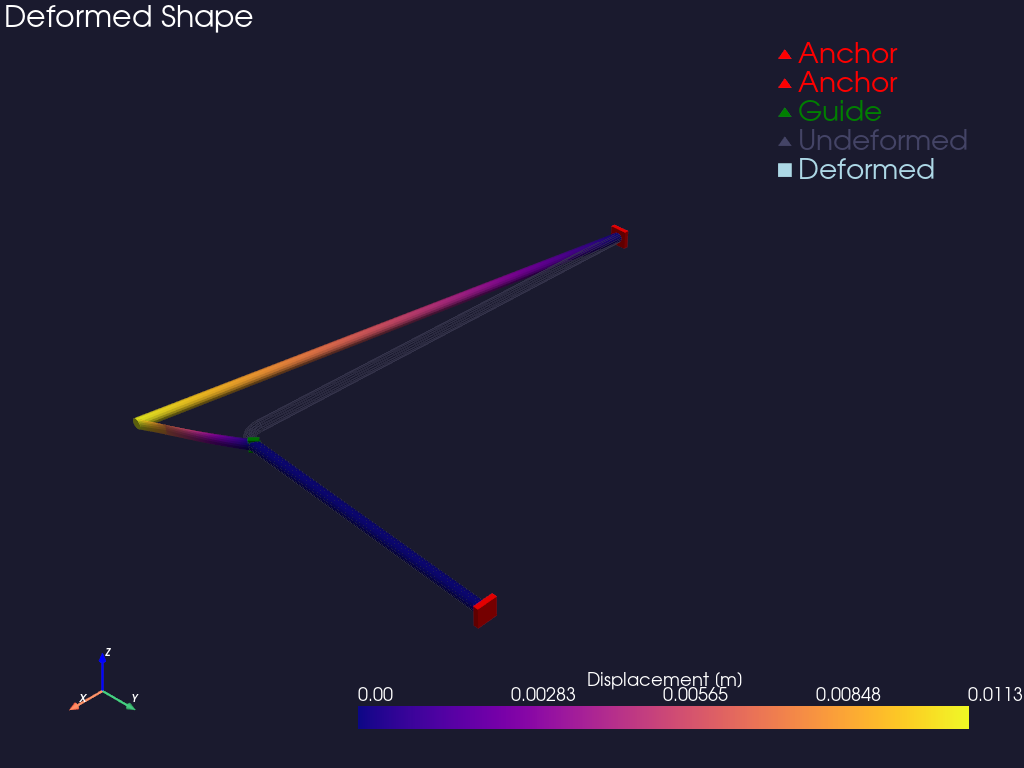

In [5]:
plots.plot_deformed(results, scale=100.0, model=model, jupyter_backend=JUPYTER_BACKEND)

### C. Stress Distribution Only

Use this when you want stress contours on the undeformed model.


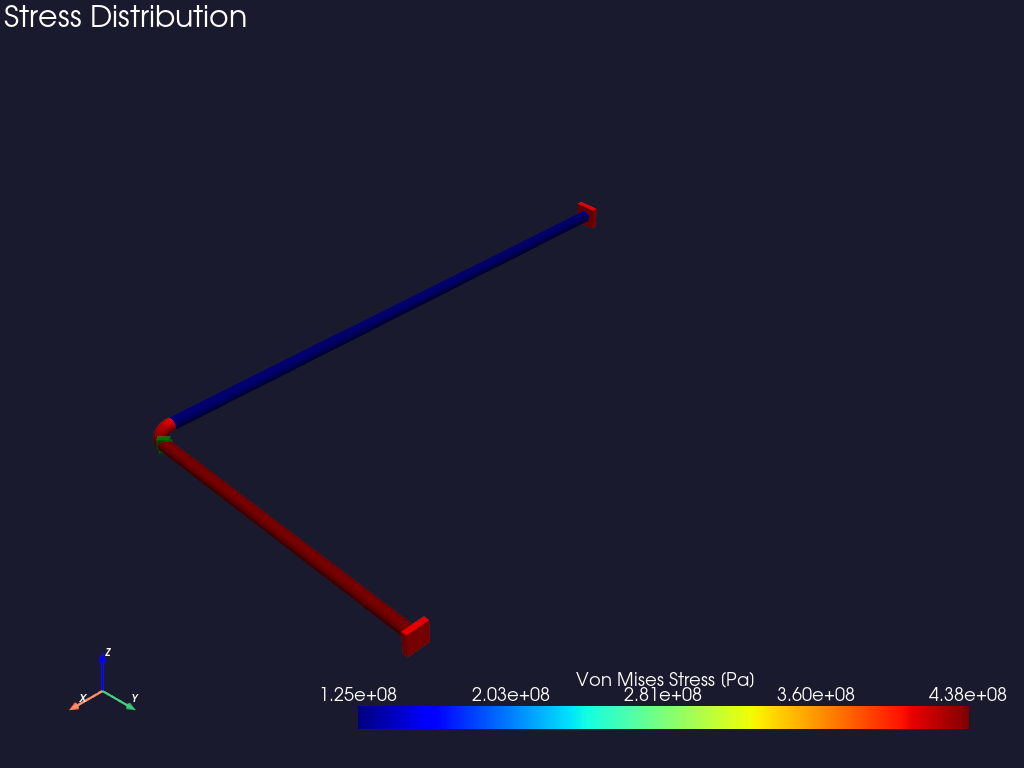

In [6]:
plots.plot_stress(results, model=model, jupyter_backend=JUPYTER_BACKEND)

### D. Displacement Vectors and Support Reactions

Use these views to inspect directional movement and reaction forces at restrained nodes.


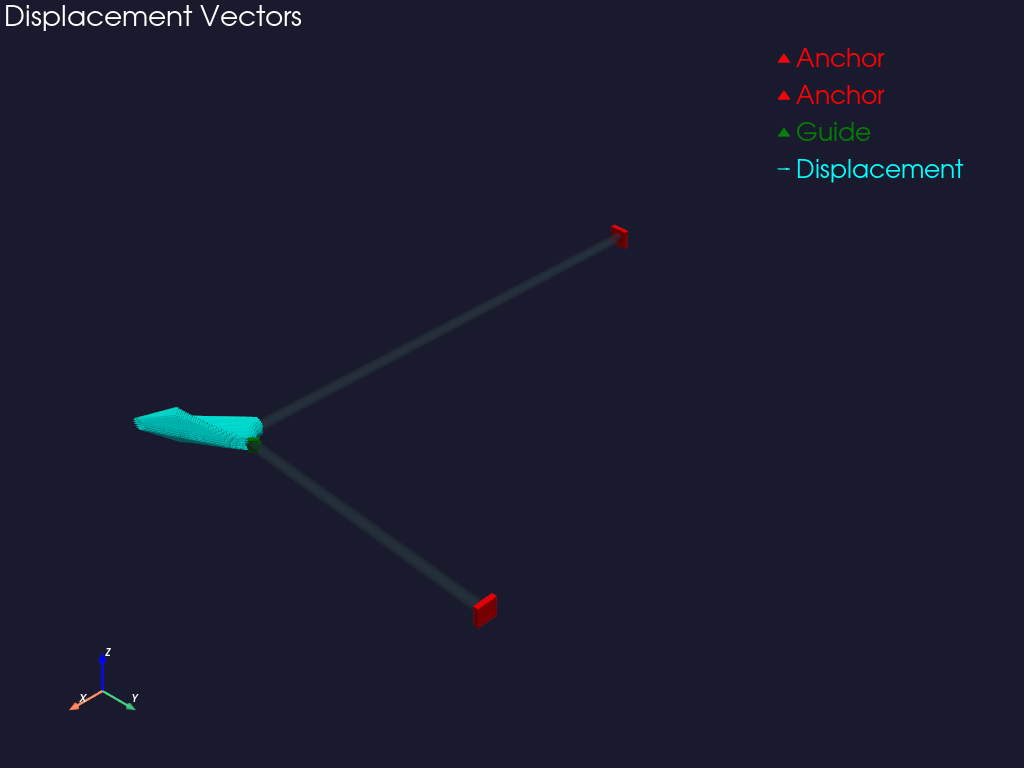

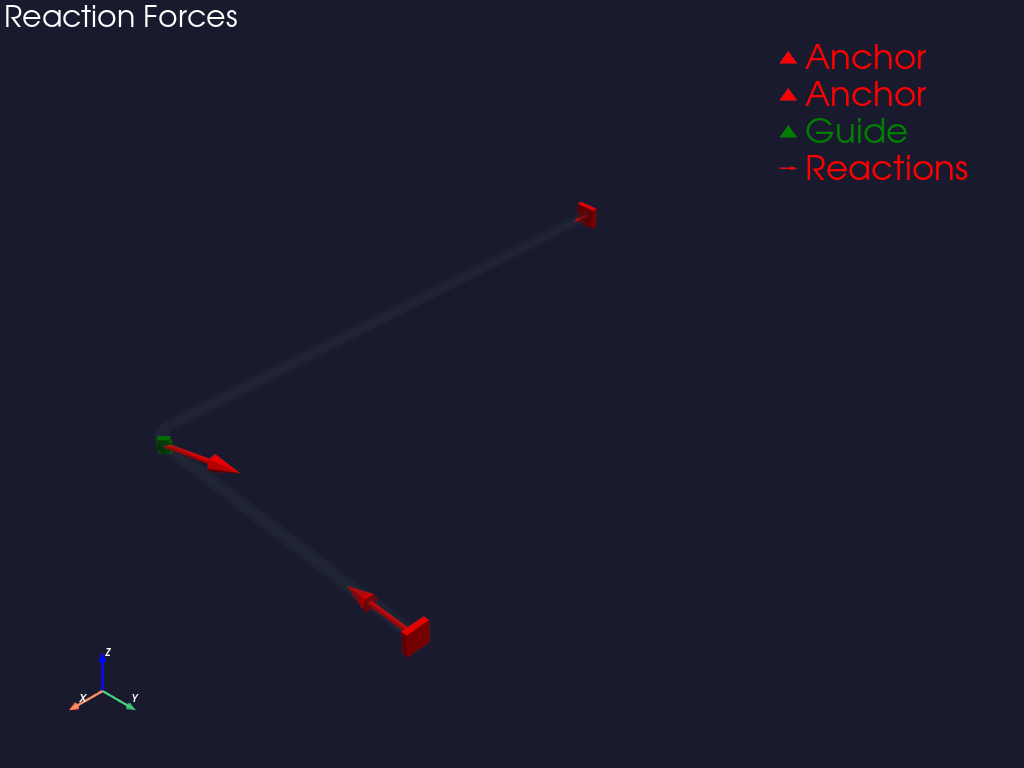

In [7]:
# Plot displacements as arrows
plots.plot_displacement_vectors(results, scale=100.0, model=model, jupyter_backend=JUPYTER_BACKEND)

# Plot support reactions
plots.plot_reactions(results, scale="auto", model=model, geometry_opacity=0.2, jupyter_backend=JUPYTER_BACKEND)

## 5. ASME B31.3 Compliance Checking

The `ASMEB313Evaluator` checks every element end for:
1. **Sustained Stress ($S_L$):** Pressure + Weight stress must be less than hot allowable stress $S_h$.
2. **Expansion Stress ($S_E$):** Thermal expansion stress must be less than allowable expansion range $S_A = f(1.25 S_c + 0.25 S_h)$.

In [8]:
evaluator = ASMEB313Evaluator()
report = evaluator.evaluate(model, results)

print(f"ASME B31.3 Compliance Check Results:")
print(f"  Overall Pass: {report.overall_pass}")
print(f"  Worst Sustained Stress Ratio: {report.worst_sustained_ratio:.3f}")
print(f"  Worst Expansion Stress Ratio: {report.worst_expansion_ratio:.3f}")

ASME B31.3 Compliance Check Results:
  Overall Pass: False
  Worst Sustained Stress Ratio: 8.423
  Worst Expansion Stress Ratio: 4.980


### Traceability: Detailed Calculations

A key feature of Tuba's compliance module is **mathematical traceability**. You can extract a step-by-step calculation trace formatted in Markdown/LaTeX for any element.

In [9]:
from IPython.display import display, Markdown

# Get calculation trace for the straight pipe element
trace_md = report.get_detailed_calculation("pipe_str_0")
display(Markdown(trace_md[:1500] + "\n... [truncated] ..."))

# ASME B31.3 Detailed Calculation — Element `pipe_str_0`

## Node `N0`

### 1. Input Values

| Quantity | Symbol | Value |
|----------|--------|------:|
| Outer diameter | $D_o$ | 114.30 mm |
| Corroded wall thickness | $t$ | 5.020 mm |
| Section modulus | $Z$ | 45.1113 mm^3 × 10^6 |
| Internal pressure | $P$ | 1.500 MPa |
| In-plane moment resultant | $M_i$ | 9899.33 N·m |
| Out-of-plane moment | $M_o$ | 0.00 N·m |
| Torsional moment | $M_t$ | 0.00 N·m |
| Hot allowable stress | $S_h$ | 120.00 MPa |
| Cold allowable stress | $S_c$ | 137.00 MPa |

### 2. Stress Intensification Factors

Straight pipe — $i_i = i_o = 1.0$, $k = 1.0$.

### 3. Sustained Stress (§302.3.5)

$$
S_L = \frac{P \cdot D_o}{4 t} + \frac{\sqrt{(i_i \cdot M_i)^2 + (i_o \cdot M_o)^2}}{Z}
$$

$$
S_L = \frac{1.500 \times 114.30}{4 \times 5.020} + \frac{\sqrt{(1.0000 \times 9899.33)^2 + (1.0000 \times 0.00)^2}}{4.511126e-05}
$$

$$
S_L = 8.538 + 219.443 = 227.981 \;\text{MPa}
$$

Allowable $S_h = 120.00$ MPa — Ratio $= 1.900$ — ❌ FAIL

### 4. Expansion Stress (§302.3.5(d))

$$
S_E = \frac{\sqrt{(i_i \cdot M_i)^2 + (i_o \cdot M_o)^2 + M_t^2}}{Z}
$$

$$
S_E = \frac{\sqrt{(1.0000 \times 9899.33)^2 + (1.0000 \times 0.00)^2 + 0.00^2}}{4.511126e-05} = 219.443 \;\text{MPa}
$$

### 5. Allowable Expansion Stress

$$
S_A = f \left(1.25\,S_c + 0.25\,S_h\right) = 1.0 \times \left(1.25 \times 137.00 + 0.25 \times 120.00\right) = 201.25 \;\text{MPa}
$$

Ratio $= 1.090$ — ❌ FAIL

---

## Node `N1`

### 1. Input Values

| Quan
... [truncated] ...

## 6. SIF Computation at Tees

Stress Intensification Factors (SIFs) are used to account for stress concentrations at fittings (bends, Tees). Let's construct a branch connection model to compute the out-of-plane and in-plane SIFs.

In [10]:
model2 = Model("TeeDemo")
model2.add_material("Steel", E=2.0e11, nu=0.3, alpha=1.2e-5, rho=7850)
model2.add_pipe_section("RunPipe", OD=0.1683, WT=0.0071)

# Create main run with midpoint node N1
with model2.pipe(section="RunPipe", material="Steel") as b:
    b.start([0, 0, 0]).run(2.0).run(2.0).end()

# Branch connection starting at N1
with model2.pipe(section="RunPipe", material="Steel") as b:
    b.start([2.0, 0.0, 0.0]).set_direction([0.0, 1.0, 0.0]).run(1.5).end()

# Define N1 as a welding Tee fitting
model2.define_tee("N1", type="welding_tee")

# Calculate legacy Appendix-D SIFs for the run element connected to the Tee.
# Production B31J tee checks require licensed Table 1-1 data.
run_element = model2.elements[0]
i_i, i_o, k, h = compute_sifs(
    run_element,
    model2,
    node_id="N1",
    allow_appendix_d_tee=True,
)

print(f"Welding Tee SIF results at node N1:")
print(f"  In-plane SIF (i_i): {i_i:.3f}")
print(f"  Out-of-plane SIF (i_o): {i_o:.3f}")
print(f"  Flexibility factor (k): {k:.3f}")
print(f"  Characteristic (h): {h:.3f}")

Welding Tee SIF results at node N1:
  In-plane SIF (i_i): 1.693
  Out-of-plane SIF (i_o): 1.693
  Flexibility factor (k): 1.000
  Characteristic (h): 0.388


## Key Takeaways

- Code_Aster output tables are the source for every stress, deformation, and reaction display in this notebook.
- `load_or_run_code_aster_results(...)` is the notebook boundary between model authoring and result visualization.
- `ASMEB313Evaluator` checks sustained and expansion stress ratios against ASME B31.3 limits.
- TUYAU `SOUS_POINT` rows keep the raw Code_Aster centerline coordinates plus shell display positions computed from Code_Aster's validated fibre formula.
- Detailed markdown traces make compliance calculations reviewable.
- SIF helpers cover branch and fitting stress-intensification checks.

Next: `04_visualization_gallery.ipynb` exports the same verified results into review formats for different audiences.
